# EDA 작업 노트북 - Phase 3: smp_rt (실시간 SMP, 실제 예측 대상)

- 대상: **`smp_rt_hourly_mean`** (제주 실시간 SMP, g1~g4 평균) = 본 프로젝트의 실제 모델링 타깃. 이 노트북에서 `smp_rt` = `smp_rt_hourly_mean`.
- 피처: `clean_total.csv` (33개, 타깃 없음) join 타깃: `clean_rt_smp.csv` - `timestamp` 기준 inner join
- 구간: **2024-03-01 ~ 2026-05-13** (smp_rt는 실시간 시장 개시인 2024-03-01부터 존재)
- 방침: Phase 1·2와 동일 - 단계별 그래프 + 동일 내용 텍스트 리포트, 단기 예측 관점
- Phase 2 결과: 2024-06 이후 SMP 구조가 바뀜. smp_jeju는 AR(1)~AR(2)로 "어제≈오늘"이 이미 알려짐.
- Phase 3 핵심 질문: **day-ahead `smp_jeju`를 실시간 `smp_rt` 예측의 baseline으로 쓸 수 있는가? 어디서 조심해야 하나?**
- 주의: `smp_rt_daily_*` 컬럼은 하루 1값이 시간마다 broadcast됨 → 일별로 쓸 땐 `resample('D').first()`, 재집계 금지.

구성: Step 0 점검 · Step 1 단순비교 · Step 2 시간대/계절 · Step 3 음SMP · Step 4 격차분포(시간·계절·계절x시간) · Step 5 DA-RT 상관(해상도x집계) · Step 6 DA vs same-hour naive

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.font_manager as fm
import platform
from matplotlib import font_manager, rc

# 1. 마이너스 기호 깨짐 방지를 최상단에 먼저 설정
plt.rcParams['axes.unicode_minus'] = False

# 2. 운영체제에 따른 폰트 설정
if platform.system() == 'Windows':
    # 맑은 고딕을 인식할 수 있도록 시스템 이름과 영문 이름을 모두 리스트로 지정
    rc('font', family=['Malgun Gothic', 'sans-serif'])

# 피처 테이블 (clean_total, cp949) - 타깃 컬럼 없음
feat = pd.read_csv('clean_total.csv', index_col='timestamp', parse_dates=True, encoding='cp949')

# 타깃 테이블 (clean_rt_smp) - 실시간 SMP, 2024-03-01부터
rt = pd.read_csv('clean_rt_smp.csv', index_col='timestamp', parse_dates=True)

# timestamp 기준 inner join → smp_rt 존재 구간만 남음
df = feat.join(rt, how='inner')

TARGET = 'smp_rt_hourly_mean'         # 시간별 타깃 = g1~g4 평균  (= 'smp_rt')
CUT    = pd.Timestamp('2024-06-01')   # Phase 2의 jeju/land 레짐 분기점 (RT는 이전 데이터가 적음)

# 수요가중 일평균 헬퍼 : sum(price x real_demand) / sum(real_demand)
def daily_wavg(col):
    num = (df[col] * df['real_demand']).resample('D').sum()
    den = df['real_demand'].resample('D').sum()
    return num / den

# 계절 매핑 (Step 4·5·6 공통) : 봄 3-5 / 여름 6-8 / 가을 9-11 / 겨울 12-2
SEASON = {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
          6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을'}
SEASON_ORDER = ['봄', '여름', '가을', '겨울']

def season_of(idx):
    return pd.Series(idx.month, index=idx).map(SEASON)

print('데이터 로드 완료')
print(f'  feat : {feat.shape}  ({feat.index.min().date()} ~ {feat.index.max().date()})')
print(f'  rt   : {rt.shape}  ({rt.index.min().date()} ~ {rt.index.max().date()})')
print(f'  df   : {df.shape}  ({df.index.min().date()} ~ {df.index.max().date()})  [inner join]')
print()
print(f'타깃 = {TARGET}  (= smp_rt)')
cols = ['g1', 'g2', 'g3', 'g4', TARGET, 'smp_rt_daily_wavg',
        'smp_rt_daily_max', 'smp_rt_daily_min', 'smp_rt_neg_flag']
print(df[cols].describe().round(2).to_string())

데이터 로드 완료
  feat : (55800, 32)  (2020-01-01 ~ 2026-05-13)
  rt   : (19320, 9)  (2024-03-01 ~ 2026-05-14)
  df   : (19296, 41)  (2024-03-01 ~ 2026-05-13)  [inner join]

타깃 = smp_rt_hourly_mean  (= smp_rt)
             g1        g2        g3        g4  smp_rt_hourly_mean  smp_rt_daily_wavg  smp_rt_daily_max  smp_rt_daily_min
count  19296.00  19296.00  19296.00  19296.00            19296.00           19296.00          19296.00          19296.00
mean     113.21    113.34    113.11    112.93              113.15             115.56            150.85             43.65
std       42.46     42.21     42.25     42.57               40.78              20.63             29.72             71.18
min      -79.32    -79.32    -79.32    -79.32              -79.32              42.76             71.52            -79.32
25%       97.87     97.89     97.87     97.81               97.41             101.92            133.35             -2.00
50%      118.82    118.88    118.76    118.73              118.47     

## Step 0 - 데이터 / 커버리지 점검

**목표**: join 결과·결측·중복·일별 broadcast 여부·2024-06 전후 표본수를 확인. (RT는 2024-06 이전이 매우 적어 pre/post 비교가 불안정함을 명시)

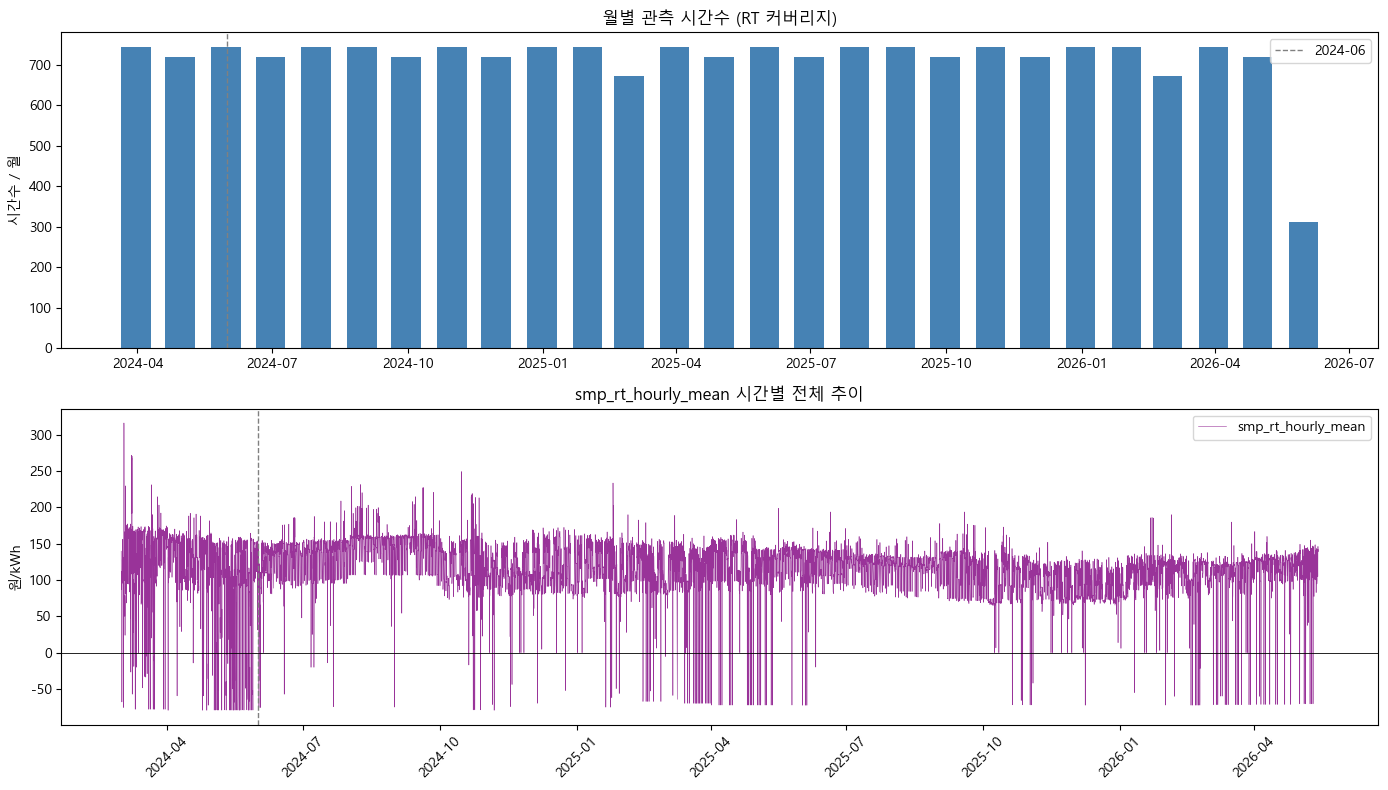

[Step 0] 데이터 / 커버리지 점검 리포트
join shape         : (19296, 41)  (2024-03-01 00:00:00 ~ 2026-05-13 23:00:00)
중복 timestamp     : 0개
타깃 결측(NaN)     : 0개
일별 broadcast 확인: smp_rt_daily_max 하루당 고유값 평균 1.00 (1이면 하루 1값)
2024-06 이전 표본  : 2208시간   2024-06 이후 : 17088시간
타깃 음 비율       : 2.88%   smp_rt_neg_flag : 4.22%

→ 2024-06 이전 RT 표본이 매우 적으면(<3개월) pre/post RT 비교는 통계적으로 불안정.
  Phase 3는 RT 구간을 대부분 2024-06 이후 레짐으로 간주하고 RT 내부 구조에 집중.


In [3]:
monthly_cnt = df[TARGET].resample('ME').count()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.bar(monthly_cnt.index, monthly_cnt.values, width=20, color='steelblue')
ax.axvline(CUT, color='gray', linestyle='--', linewidth=1, label='2024-06')
ax.set_title('월별 관측 시간수 (RT 커버리지)')
ax.set_ylabel('시간수 / 월')
ax.legend()

ax = axes[1]
ax.plot(df.index, df[TARGET], color='purple', linewidth=0.4, alpha=0.8, label='smp_rt_hourly_mean')
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(CUT, color='gray', linestyle='--', linewidth=1)
ax.set_title('smp_rt_hourly_mean 시간별 전체 추이')
ax.set_ylabel('원/kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# 텍스트 리포트
daily_grp = df['smp_rt_daily_max'].groupby(df.index.date).nunique()
pre_n     = (df.index < CUT).sum()
post_n    = (df.index >= CUT).sum()

print('=' * 60)
print('[Step 0] 데이터 / 커버리지 점검 리포트')
print('=' * 60)
print(f'join shape         : {df.shape}  ({df.index.min()} ~ {df.index.max()})')
print(f'중복 timestamp     : {df.index.duplicated().sum()}개')
print(f'타깃 결측(NaN)     : {df[TARGET].isna().sum()}개')
print(f'일별 broadcast 확인: smp_rt_daily_max 하루당 고유값 평균 {daily_grp.mean():.2f} (1이면 하루 1값)')
print(f'2024-06 이전 표본  : {pre_n}시간   2024-06 이후 : {post_n}시간')
print(f'타깃 음 비율       : {(df[TARGET] < 0).mean()*100:.2f}%   smp_rt_neg_flag : {df["smp_rt_neg_flag"].mean()*100:.2f}%')
print()
print('→ 2024-06 이전 RT 표본이 매우 적으면(<3개월) pre/post RT 비교는 통계적으로 불안정.')
print('  Phase 3는 RT 구간을 대부분 2024-06 이후 레짐으로 간주하고 RT 내부 구조에 집중.')

## Step 1 - 단순 비교 (레벨 · 집계)

**목표**: `smp_jeju`(시간/수요가중 일평균/일 min·max·mean) vs `smp_rt`(시간별/일 wavg·min·max·mean)를 단순 추이로 비교. 레벨 상관은 추세에 의해 과장되므로 1차 차분 상관도 함께 본다 (Phase-1 교훈).

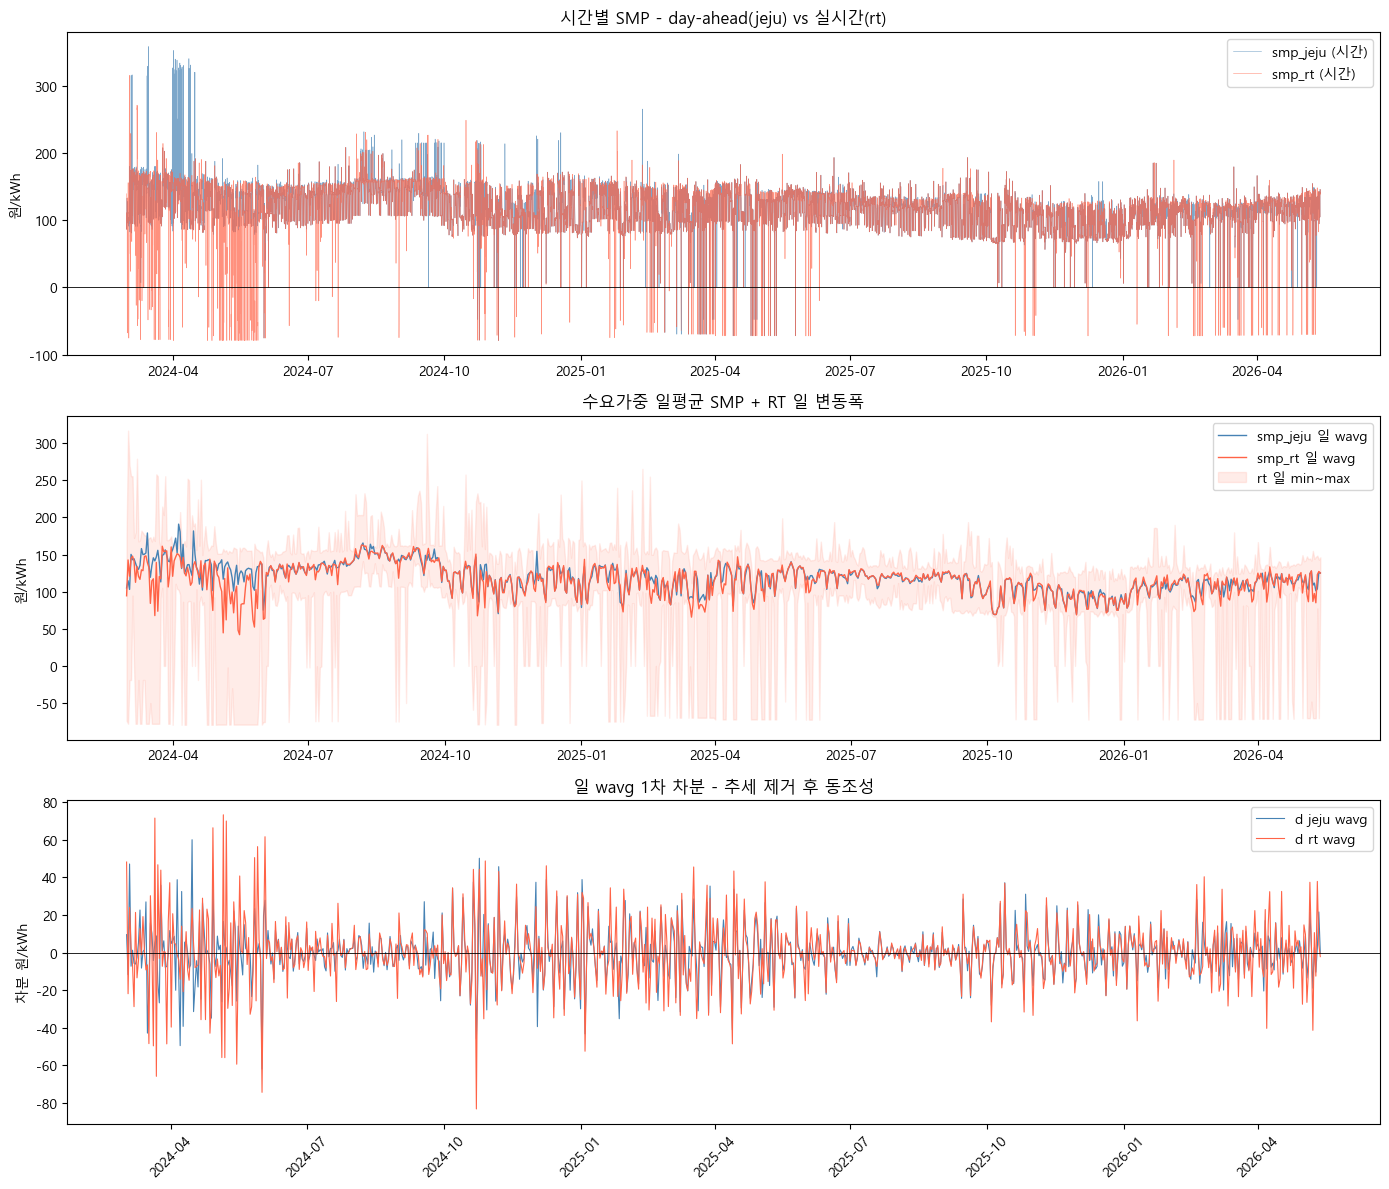

[Step 1] 단순 비교 (레벨 · 집계) 리포트
       smp_jeju (시간)  smp_rt (시간)  jeju 일 wavg  rt 일 wavg
count       19296.00     19296.00       804.00     804.00
mean          117.04       113.15       118.80     115.46
std            32.01        40.78        19.06      20.65
min           -79.28       -79.32        69.14      42.08
25%            99.33        97.41       106.44     101.71
50%           117.84       118.47       119.39     117.71
75%           137.60       138.31       130.75     128.94
max           359.18       316.23       191.00     162.81

상관 (시간별 레벨)        : 0.592
상관 (일 wavg 레벨)       : 0.831
상관 (일 wavg 1차 차분)   : 0.708

→ 레벨 상관 >> 차분 상관이면 함께 움직인다는 대부분 공통 추세(허위).
  RT가 jeju보다 변동폭(표준편차·일 min~max)이 크면 day-ahead로 RT를 그대로 쓰기 어렵다는 신호.


In [4]:
jeju_wavg = daily_wavg('smp_jeju')
rt_wavg   = daily_wavg(TARGET)
rt_dmax   = df['smp_rt_daily_max'].resample('D').first()
rt_dmin   = df['smp_rt_daily_min'].resample('D').first()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

ax = axes[0]
ax.plot(df.index, df['smp_jeju'], color='steelblue', linewidth=0.4, alpha=0.7, label='smp_jeju (시간)')
ax.plot(df.index, df[TARGET],     color='tomato',    linewidth=0.4, alpha=0.7, label='smp_rt (시간)')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('시간별 SMP - day-ahead(jeju) vs 실시간(rt)')
ax.set_ylabel('원/kWh'); ax.legend()

ax = axes[1]
ax.plot(jeju_wavg.index, jeju_wavg.values, color='steelblue', linewidth=1.0, label='smp_jeju 일 wavg')
ax.plot(rt_wavg.index,   rt_wavg.values,   color='tomato',    linewidth=1.0, label='smp_rt 일 wavg')
ax.fill_between(rt_dmin.index, rt_dmin.values, rt_dmax.values, color='tomato', alpha=0.12, label='rt 일 min~max')
ax.set_title('수요가중 일평균 SMP + RT 일 변동폭')
ax.set_ylabel('원/kWh'); ax.legend()

ax = axes[2]
ax.plot(jeju_wavg.index, jeju_wavg.diff().values, color='steelblue', linewidth=0.8, label='d jeju wavg')
ax.plot(rt_wavg.index,   rt_wavg.diff().values,   color='tomato',    linewidth=0.8, label='d rt wavg')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('일 wavg 1차 차분 - 추세 제거 후 동조성')
ax.set_ylabel('차분 원/kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45); ax.legend()

plt.tight_layout()
plt.show()

# 텍스트 리포트
stat = pd.DataFrame({
    'smp_jeju (시간)':  df['smp_jeju'].describe(),
    'smp_rt (시간)':    df[TARGET].describe(),
    'jeju 일 wavg':     jeju_wavg.describe(),
    'rt 일 wavg':       rt_wavg.describe(),
}).round(2)

corr_hr   = df[['smp_jeju', TARGET]].corr().iloc[0, 1]
corr_wavg = pd.concat([jeju_wavg, rt_wavg], axis=1).corr().iloc[0, 1]
corr_diff = pd.concat([jeju_wavg.diff(), rt_wavg.diff()], axis=1).corr().iloc[0, 1]

print('=' * 60)
print('[Step 1] 단순 비교 (레벨 · 집계) 리포트')
print('=' * 60)
print(stat.to_string())
print()
print(f'상관 (시간별 레벨)        : {corr_hr:.3f}')
print(f'상관 (일 wavg 레벨)       : {corr_wavg:.3f}')
print(f'상관 (일 wavg 1차 차분)   : {corr_diff:.3f}')
print()
print('→ 레벨 상관 >> 차분 상관이면 함께 움직인다는 대부분 공통 추세(허위).')
print('  RT가 jeju보다 변동폭(표준편차·일 min~max)이 크면 day-ahead로 RT를 그대로 쓰기 어렵다는 신호.')

## Step 2 - 시간대 · 계절 비교

**목표**: 0~23시 시간대별, 1~12월 계절별로 `smp_jeju` vs `smp_rt`(mean·max·min) 구조 차이를 본다. Phase-2에서 본 한낮 태양광 효과가 실제 타깃에서 더 강한지 확인.

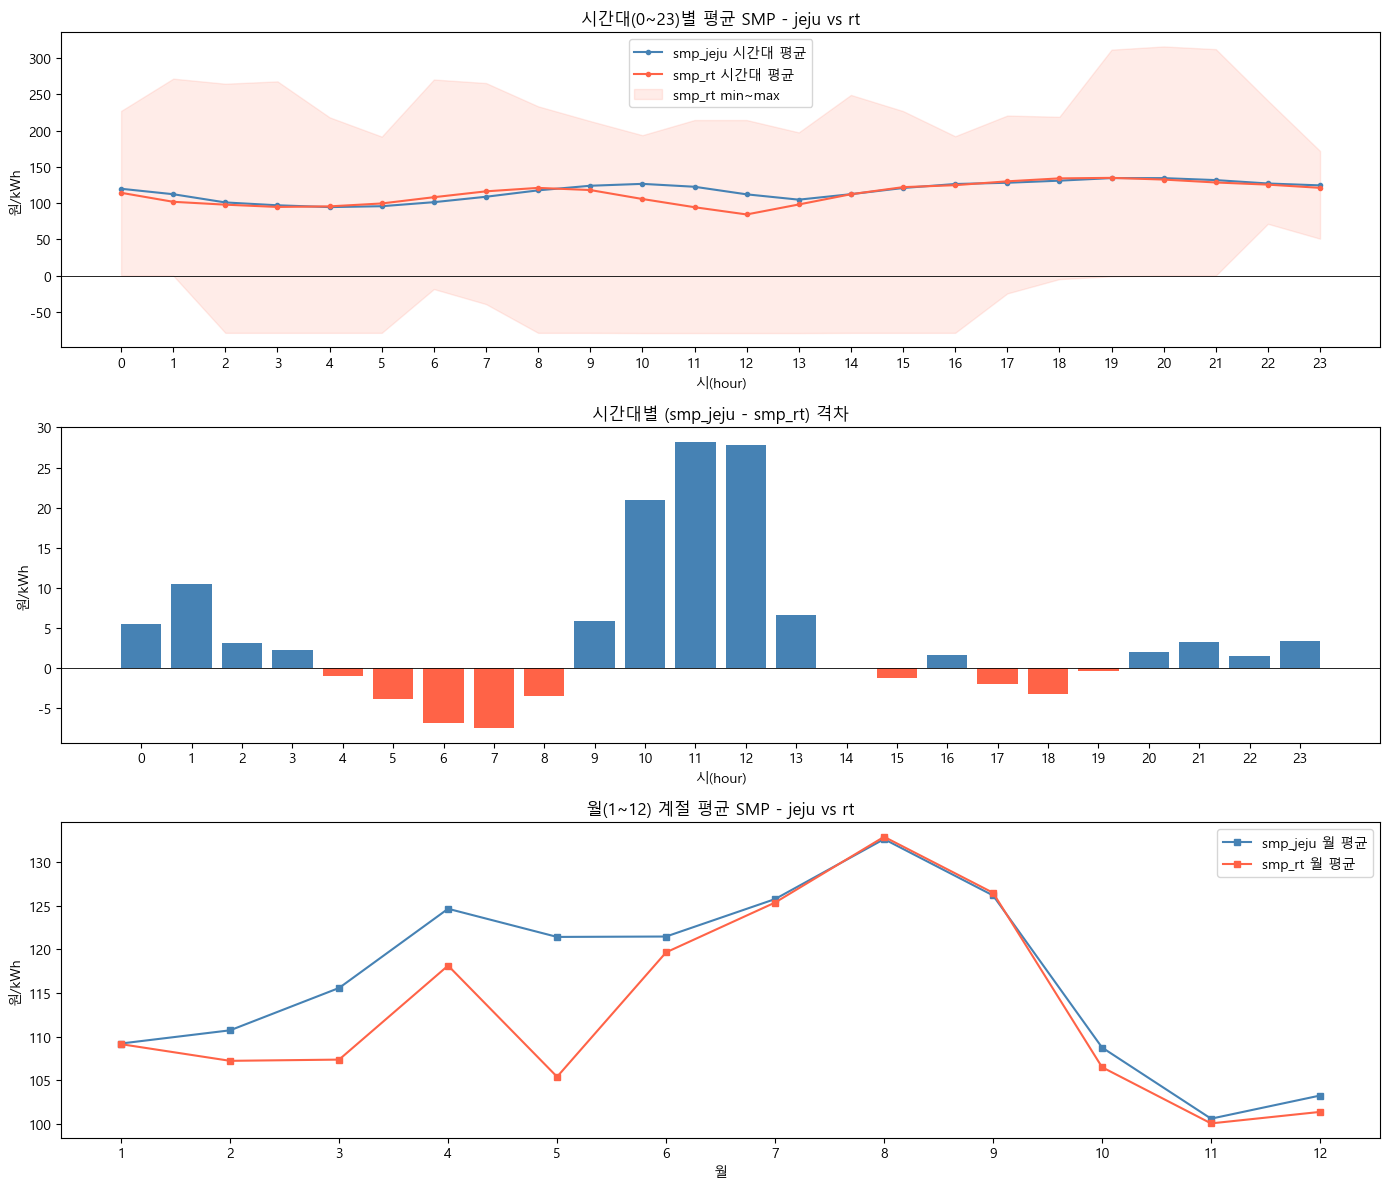

[Step 2] 시간대 · 계절 비교 리포트
[시간대별 평균 (원/kWh)]
             jeju      rt  jeju-rt
timestamp                         
0          119.81  114.25     5.57
1          112.28  101.82    10.46
2          100.94   97.86     3.08
3           97.00   94.71     2.29
4           94.50   95.51    -1.00
5           95.73   99.54    -3.81
6          101.30  108.16    -6.87
7          108.78  116.26    -7.48
8          117.61  121.02    -3.41
9          123.97  118.06     5.91
10         126.58  105.68    20.90
11         122.58   94.35    28.23
12         112.12   84.36    27.76
13         104.78   98.13     6.65
14         112.33  112.27     0.06
15         120.85  122.05    -1.20
16         126.39  124.77     1.62
17         128.10  130.08    -1.97
18         130.97  134.15    -3.18
19         134.56  134.87    -0.31
20         134.50  132.51     1.99
21         131.78  128.49     3.29
22         127.10  125.52     1.58
23         124.49  121.09     3.40

격차 최소(=RT가 가장 비싼/jeju 싼) : 7시 (-7.5)
격차 최대(=RT

In [5]:
h = df.index.hour
m = df.index.month

jeju_h = df['smp_jeju'].groupby(h).mean()
rt_h   = df[TARGET].groupby(h).mean()
rt_hmx = df[TARGET].groupby(h).max()
rt_hmn = df[TARGET].groupby(h).min()
gap_h  = jeju_h - rt_h

jeju_m = df['smp_jeju'].groupby(m).mean()
rt_m   = df[TARGET].groupby(m).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

ax = axes[0]
ax.plot(jeju_h.index, jeju_h.values, color='steelblue', marker='o', markersize=3, label='smp_jeju 시간대 평균')
ax.plot(rt_h.index,   rt_h.values,   color='tomato',    marker='o', markersize=3, label='smp_rt 시간대 평균')
ax.fill_between(rt_hmn.index, rt_hmn.values, rt_hmx.values, color='tomato', alpha=0.12, label='smp_rt min~max')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('시간대(0~23)별 평균 SMP - jeju vs rt')
ax.set_xlabel('시(hour)'); ax.set_ylabel('원/kWh'); ax.set_xticks(range(0, 24)); ax.legend()

ax = axes[1]
ax.bar(gap_h.index, gap_h.values, color=['tomato' if v < 0 else 'steelblue' for v in gap_h.values])
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('시간대별 (smp_jeju - smp_rt) 격차')
ax.set_xlabel('시(hour)'); ax.set_ylabel('원/kWh'); ax.set_xticks(range(0, 24))

ax = axes[2]
ax.plot(jeju_m.index, jeju_m.values, color='steelblue', marker='s', markersize=4, label='smp_jeju 월 평균')
ax.plot(rt_m.index,   rt_m.values,   color='tomato',    marker='s', markersize=4, label='smp_rt 월 평균')
ax.set_title('월(1~12) 계절 평균 SMP - jeju vs rt')
ax.set_xlabel('월'); ax.set_ylabel('원/kWh'); ax.set_xticks(range(1, 13)); ax.legend()

plt.tight_layout()
plt.show()

# 텍스트 리포트
print('=' * 60)
print('[Step 2] 시간대 · 계절 비교 리포트')
print('=' * 60)
print('[시간대별 평균 (원/kWh)]')
print(pd.DataFrame({'jeju': jeju_h.round(2), 'rt': rt_h.round(2),
                    'jeju-rt': gap_h.round(2)}).to_string())
print()
print(f'격차 최소(=RT가 가장 비싼/jeju 싼) : {gap_h.idxmin()}시 ({gap_h.min():.1f})')
print(f'격차 최대(=RT가 가장 싼)          : {gap_h.idxmax()}시 (+{gap_h.max():.1f})')
print()
print('[월별 평균 (원/kWh)]')
print(pd.DataFrame({'jeju': jeju_m.round(2), 'rt': rt_m.round(2)}).to_string())
print()
print('→ 한낮(태양광) 시간대에서 rt가 jeju보다 크게 싸지면(격차 +) 실시간 시장이 day-ahead와 구조적으로 분리.')

## Step 3 - 음 SMP 기간 비교

**목표**: 음(-) SMP가 `smp_jeju`보다 `smp_rt`에서 더 넓게(더 일찍·더 자주) 발생하는지 단순 추이로 확인.

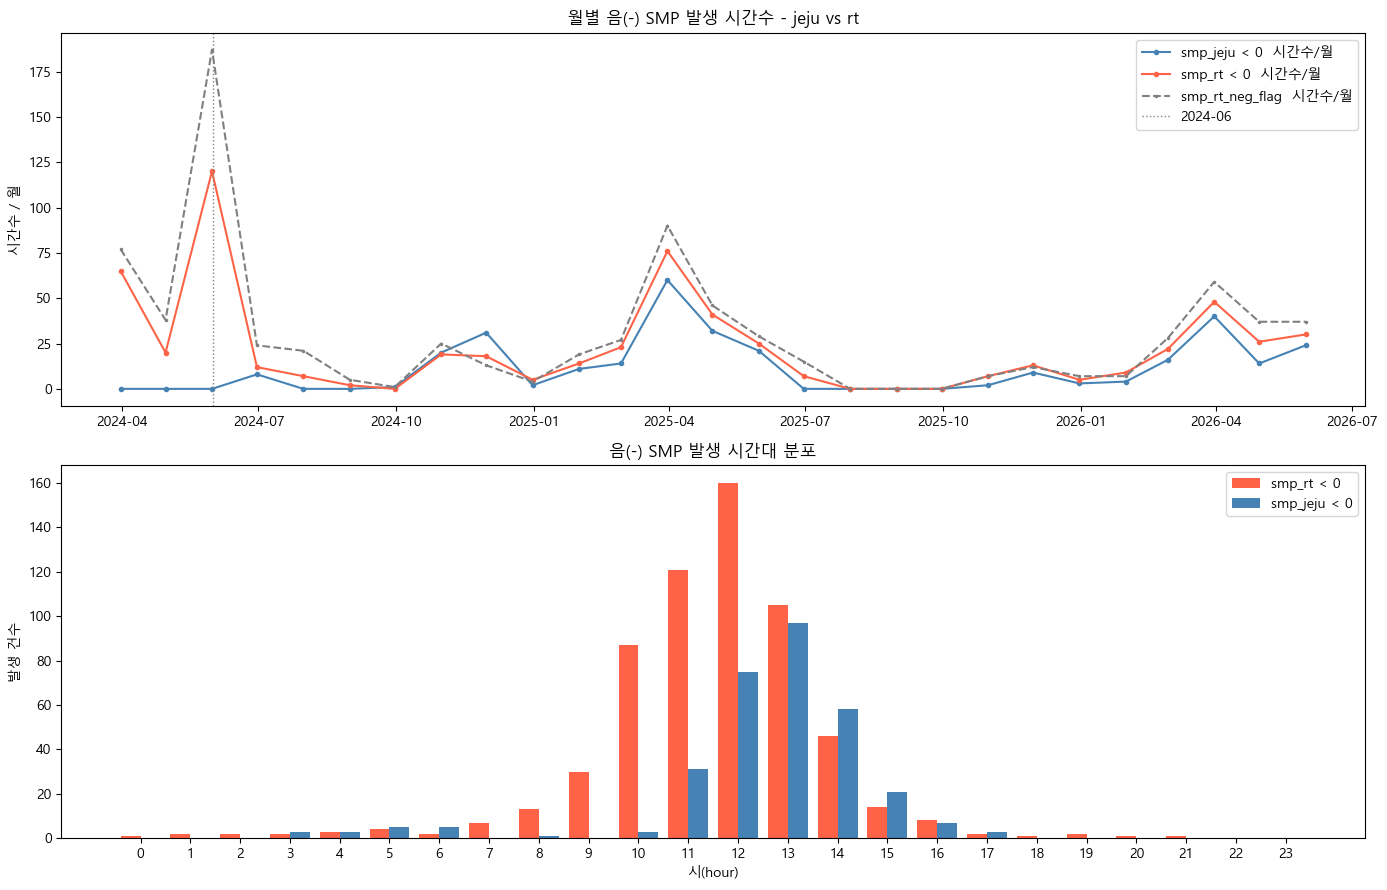

[Step 3] 음(-) SMP 기간 비교 리포트
smp_jeju 음SMP 최초 : 2024-06-01 11:00:00
smp_rt   음SMP 최초 : 2024-03-01 10:00:00
smp_jeju 음SMP 총 312시간  (1.62%)
smp_rt   음SMP 총 614시간  (3.18%)
neg_flag      총 815시간  (4.22%)

[음 smp_rt 상위 발생 시간대 TOP5 (시 : 건수)]
timestamp
12    160
11    121
13    105
10     87
14     46

→ rt 음SMP가 더 일찍 시작하고 비율이 jeju보다 훨씬 크면, RT의 음 구간이 더 넓다(가설 확인).


In [6]:
neg_jeju = (df['smp_jeju'] < 5)
neg_rt   = (df[TARGET]     < 5)
neg_flag = df['smp_rt_neg_flag'].astype(bool)

mneg_jeju = neg_jeju.resample('ME').sum()
mneg_rt   = neg_rt.resample('ME').sum()
mneg_flag = neg_flag.resample('ME').sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(mneg_jeju.index, mneg_jeju.values, color='steelblue', marker='o', markersize=3, label='smp_jeju < 0  시간수/월')
ax.plot(mneg_rt.index,   mneg_rt.values,   color='tomato',    marker='o', markersize=3, label='smp_rt < 0  시간수/월')
ax.plot(mneg_flag.index, mneg_flag.values, color='gray',      marker='.', markersize=3, linestyle='--', label='smp_rt_neg_flag  시간수/월')
ax.axvline(CUT, color='gray', linestyle=':', linewidth=1, label='2024-06')
ax.set_title('월별 음(-) SMP 발생 시간수 - jeju vs rt')
ax.set_ylabel('시간수 / 월'); ax.legend()

ax = axes[1]
hcnt_jeju = pd.Series(df[neg_jeju].index.hour).value_counts().reindex(range(24), fill_value=0).sort_index()
hcnt_rt   = pd.Series(df[neg_rt].index.hour).value_counts().reindex(range(24), fill_value=0).sort_index()
ax.bar(hcnt_rt.index - 0.2,   hcnt_rt.values,   width=0.4, color='tomato',    label='smp_rt < 0')
ax.bar(hcnt_jeju.index + 0.2, hcnt_jeju.values, width=0.4, color='steelblue', label='smp_jeju < 0')
ax.set_title('음(-) SMP 발생 시간대 분포')
ax.set_xlabel('시(hour)'); ax.set_ylabel('발생 건수'); ax.set_xticks(range(0, 24)); ax.legend()

plt.tight_layout()
plt.show()

# 텍스트 리포트
first_jeju = df.index[neg_jeju].min() if neg_jeju.any() else '없음'
first_rt   = df.index[neg_rt].min()   if neg_rt.any()   else '없음'

print('=' * 60)
print('[Step 3] 음(-) SMP 기간 비교 리포트')
print('=' * 60)
print(f'smp_jeju 음SMP 최초 : {first_jeju}')
print(f'smp_rt   음SMP 최초 : {first_rt}')
print(f'smp_jeju 음SMP 총 {int(neg_jeju.sum())}시간  ({neg_jeju.mean()*100:.2f}%)')
print(f'smp_rt   음SMP 총 {int(neg_rt.sum())}시간  ({neg_rt.mean()*100:.2f}%)')
print(f'neg_flag      총 {int(neg_flag.sum())}시간  ({neg_flag.mean()*100:.2f}%)')
print()
print('[음 smp_rt 상위 발생 시간대 TOP5 (시 : 건수)]')
print(hcnt_rt.sort_values(ascending=False).head(5).to_string())
print()
print('→ rt 음SMP가 더 일찍 시작하고 비율이 jeju보다 훨씬 크면, RT의 음 구간이 더 넓다(가설 확인).')

## Step 4 - `smp_jeju - smp_rt` 격차 분포 (시간대 + 계절 + 계절x시간)

**목표**: 격차(jeju - rt)를 ① 전체 ② 시간대별 ③ 계절별 ④ **계절x시간 평균/std** 로 본다. std가 큰 (계절,시) = day-ahead로 못 맞히는 "예측 주의" 구간 → 어디서 조심해서 예측해야 하는지 특정.

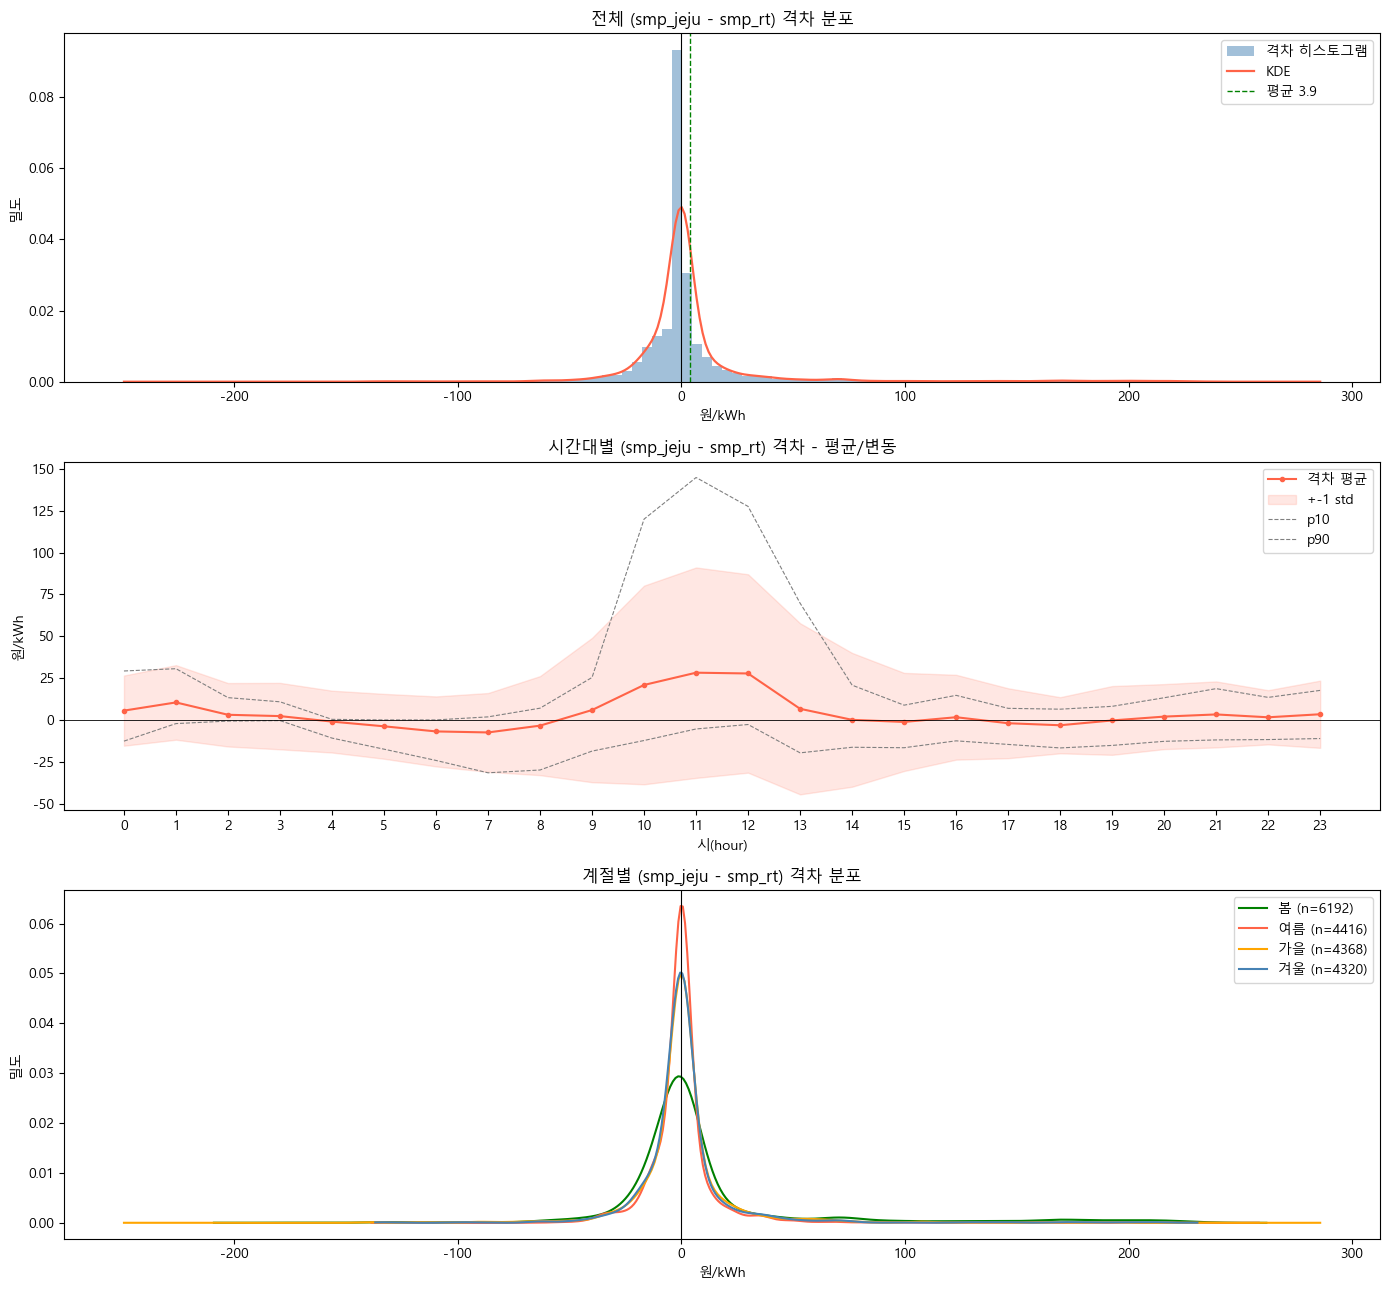

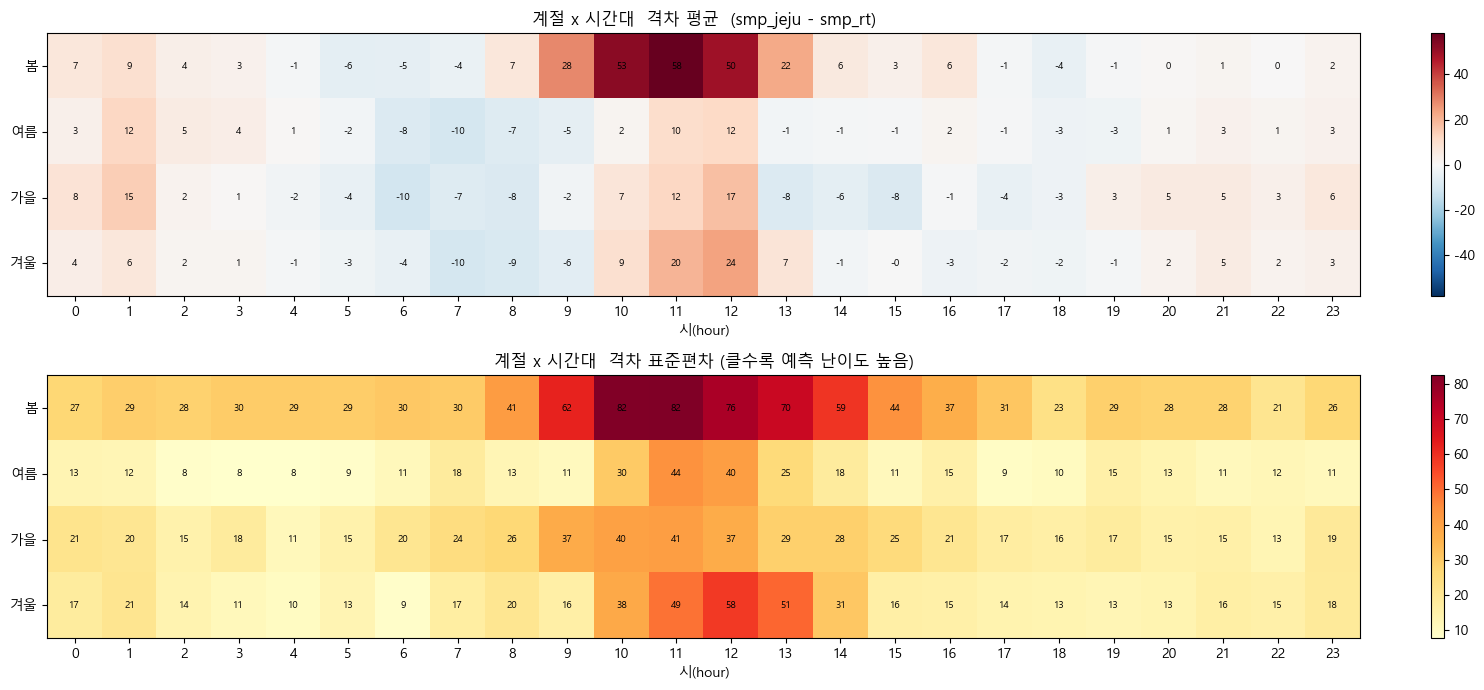

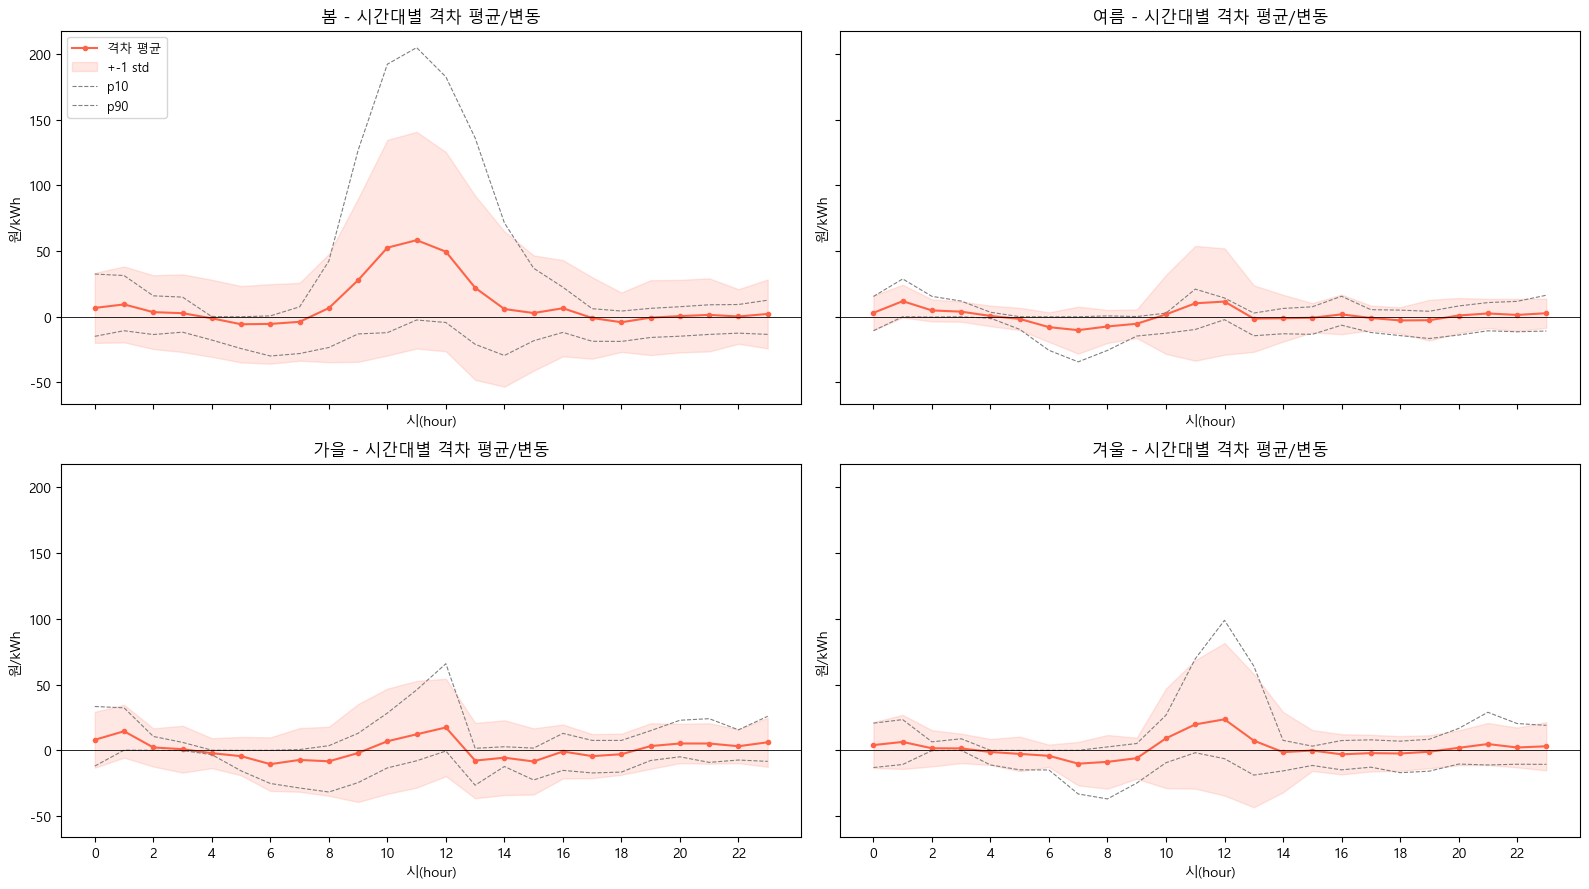

[Step 4] 격차(jeju - rt) 분포 리포트 (시간대 + 계절 + 계절x시간)
전체 평균 3.90   std 33.81   |격차|중앙값 3.06
분위수  p05 -23.74  p25 -3.93  p50 0.0  p75 2.24  p95 46.83

[시간대별 격차]
              평균    std    p10     p90
timestamp                             
0           5.57  20.97 -12.66   29.25
1          10.46  22.28  -2.18   30.61
2           3.08  18.96  -0.68   13.33
3           2.29  19.85  -0.40   10.83
4          -1.00  18.48 -10.85    0.34
5          -3.81  19.38 -17.48    0.00
6          -6.87  20.91 -24.21    0.00
7          -7.48  23.55 -31.59    1.83
8          -3.41  29.59 -29.91    7.02
9           5.91  43.13 -18.62   25.39
10         20.90  59.36 -12.30  119.99
11         28.23  62.88  -5.40  144.86
12         27.76  59.28  -2.73  127.58
13          6.65  51.13 -19.67   69.76
14          0.06  39.98 -16.33   20.78
15         -1.20  29.31 -16.61    8.83
16          1.62  25.35 -12.50   14.69
17         -1.97  20.89 -14.64    6.93
18         -3.18  16.77 -16.73    6.42
19         -0.31  20.55 -1

In [7]:
gap_s  = (df['smp_jeju'] - df[TARGET])
gap    = gap_s.dropna()
season = season_of(df.index)
hour   = pd.Series(df.index.hour, index=df.index)

try:
    from scipy.stats import gaussian_kde
    HAS_KDE = True
except Exception as e:
    HAS_KDE = False
    print(f'(KDE 생략 - scipy 없음: {e})')

# ── 그림 1 : 전체 / 시간대 / 계절 분포 ──
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

ax = axes[0]
ax.hist(gap.values, bins=120, density=True, color='steelblue', alpha=0.5, label='격차 히스토그램')
if HAS_KDE:
    xs = np.linspace(gap.min(), gap.max(), 400)
    ax.plot(xs, gaussian_kde(gap.values)(xs), color='tomato', linewidth=1.6, label='KDE')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(gap.mean(), color='green', linestyle='--', linewidth=1, label=f'평균 {gap.mean():.1f}')
ax.set_title('전체 (smp_jeju - smp_rt) 격차 분포')
ax.set_xlabel('원/kWh'); ax.set_ylabel('밀도'); ax.legend()

g_by_h = gap_s.groupby(df.index.hour)
mean_h, std_h = g_by_h.mean(), g_by_h.std()
p10_h, p90_h  = g_by_h.quantile(0.10), g_by_h.quantile(0.90)
ax = axes[1]
ax.plot(mean_h.index, mean_h.values, color='tomato', marker='o', markersize=3, label='격차 평균')
ax.fill_between(mean_h.index, (mean_h - std_h).values, (mean_h + std_h).values,
                color='tomato', alpha=0.15, label='+-1 std')
ax.plot(p10_h.index, p10_h.values, color='gray', linewidth=0.8, linestyle='--', label='p10')
ax.plot(p90_h.index, p90_h.values, color='gray', linewidth=0.8, linestyle='--', label='p90')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('시간대별 (smp_jeju - smp_rt) 격차 - 평균/변동')
ax.set_xlabel('시(hour)'); ax.set_ylabel('원/kWh'); ax.set_xticks(range(0, 24)); ax.legend()

ax = axes[2]
colors = {'봄': 'green', '여름': 'tomato', '가을': 'orange', '겨울': 'steelblue'}
for s in SEASON_ORDER:
    v = gap_s[season == s].dropna().values
    if len(v) == 0:
        continue
    if HAS_KDE:
        xs = np.linspace(v.min(), v.max(), 400)
        ax.plot(xs, gaussian_kde(v)(xs), color=colors[s], linewidth=1.5, label=f'{s} (n={len(v)})')
    else:
        ax.hist(v, bins=80, density=True, color=colors[s], alpha=0.35, label=f'{s} (n={len(v)})')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('계절별 (smp_jeju - smp_rt) 격차 분포')
ax.set_xlabel('원/kWh'); ax.set_ylabel('밀도'); ax.legend()

plt.tight_layout()
plt.show()

# ── 계절 x 시간대 통계 (그림 2·3 공용) ──
grp      = gap_s.groupby([season, hour])
piv_mean = grp.mean().unstack().reindex(SEASON_ORDER)
piv_std  = grp.std().unstack().reindex(SEASON_ORDER)
piv_p10  = grp.quantile(0.10).unstack().reindex(SEASON_ORDER)
piv_p90  = grp.quantile(0.90).unstack().reindex(SEASON_ORDER)

# ── 그림 2 : 계절 x 시간대 격차 평균 / std 히트맵 ──
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

ax = axes[0]
vmax = np.nanmax(np.abs(piv_mean.values))
im = ax.imshow(piv_mean.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(len(SEASON_ORDER))); ax.set_yticklabels(SEASON_ORDER)
for i in range(piv_mean.shape[0]):
    for k in range(piv_mean.shape[1]):
        ax.text(k, i, f'{piv_mean.values[i, k]:.0f}', ha='center', va='center', fontsize=7)
ax.set_title('계절 x 시간대  격차 평균  (smp_jeju - smp_rt)')
ax.set_xlabel('시(hour)')
fig.colorbar(im, ax=ax, fraction=0.025)

ax = axes[1]
im = ax.imshow(piv_std.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(len(SEASON_ORDER))); ax.set_yticklabels(SEASON_ORDER)
for i in range(piv_std.shape[0]):
    for k in range(piv_std.shape[1]):
        ax.text(k, i, f'{piv_std.values[i, k]:.0f}', ha='center', va='center', fontsize=7)
ax.set_title('계절 x 시간대  격차 표준편차 (클수록 예측 난이도 높음)')
ax.set_xlabel('시(hour)')
fig.colorbar(im, ax=ax, fraction=0.025)

plt.tight_layout()
plt.show()

# ── 그림 3 : 계절별 시간대 격차 - 평균 + (-+)1std + p10/p90 (계절당 1패널) ──
hrs = piv_mean.columns
ylo = float(np.nanmin([(piv_mean - piv_std).min().min(), piv_p10.min().min()]))
yhi = float(np.nanmax([(piv_mean + piv_std).max().max(), piv_p90.max().max()]))
pad = (yhi - ylo) * 0.05

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
for ax, s in zip(axes.flat, SEASON_ORDER):
    mu, sd = piv_mean.loc[s], piv_std.loc[s]
    ax.plot(hrs, mu.values, color='tomato', marker='o', markersize=3, label='격차 평균')
    ax.fill_between(hrs, (mu - sd).values, (mu + sd).values,
                    color='tomato', alpha=0.15, label='+-1 std')
    ax.plot(hrs, piv_p10.loc[s].values, color='gray', linewidth=0.8, linestyle='--', label='p10')
    ax.plot(hrs, piv_p90.loc[s].values, color='gray', linewidth=0.8, linestyle='--', label='p90')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{s} - 시간대별 격차 평균/변동')
    ax.set_xlabel('시(hour)'); ax.set_ylabel('원/kWh')
    ax.set_xticks(range(0, 24, 2)); ax.set_ylim(ylo - pad, yhi + pad)
axes.flat[0].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 텍스트 리포트
q = gap.quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(2)
h_tbl = pd.DataFrame({'평균': mean_h.round(2), 'std': std_h.round(2),
                      'p10': p10_h.round(2), 'p90': p90_h.round(2)})
s_tbl = pd.DataFrame({
    'n':        gap_s.groupby(season).count(),
    '평균':     gap_s.groupby(season).mean().round(2),
    'std':      gap_s.groupby(season).std().round(2),
    'abs중앙':  gap_s.abs().groupby(season).median().round(2),
}).reindex(SEASON_ORDER)
rank = piv_std.stack().sort_values(ascending=False)

print('=' * 60)
print('[Step 4] 격차(jeju - rt) 분포 리포트 (시간대 + 계절 + 계절x시간)')
print('=' * 60)
print(f'전체 평균 {gap.mean():.2f}   std {gap.std():.2f}   |격차|중앙값 {gap.abs().median():.2f}')
print(f'분위수  p05 {q.loc[0.05]}  p25 {q.loc[0.25]}  p50 {q.loc[0.50]}  p75 {q.loc[0.75]}  p95 {q.loc[0.95]}')
print()
print('[시간대별 격차]')
print(h_tbl.to_string())
print()
print('[계절별 격차]')
print(s_tbl.to_string())
print()
print('[계절 x 시간대 격차 평균]')
print(piv_mean.round(1).to_string())
print()
print('[계절 x 시간대 격차 std (예측 난이도)]')
print(piv_std.round(1).to_string())
print()
print('[예측 주의 구간 TOP10  (계절, 시 : std / mean)]')
for (s, hh), v in rank.head(10).items():
    print(f'  {s} {hh:>2}시   std={v:.1f}   mean={piv_mean.loc[s, hh]:.1f}')
print()
print('→ std가 큰 (계절,시)에서는 day-ahead로 RT를 못 맞힌다 → 그 구간만 조심해서 예측.')
print('  봄 한낮(10-13시)이 최상위면 사용자 직관과 일치 (태양광 과잉 → RT 급락).')


## Step 5 - day-ahead `smp_jeju` 를 RT baseline 으로 쓸 수 있나? (해상도 x 집계 상관)

**목표**: smp_jeju(어제값으로 사전 가용, AR(1)~AR(2)로 안정) - smp_rt 상관을 **시간/일/월/계절 x min·max·mean·wavg** 로 본다 (Phase 2와 유사 접근). 단, 레벨 상관만으로는 허위추세 위험 → **1차 차분 상관**, **DA를 그대로 예측치로 썼을 때 오차(bias/MAE/RMSE)**, **회귀 `rt = a + b·jeju`(기울기·R^2)**, **표본수 N** 을 함께 본다.

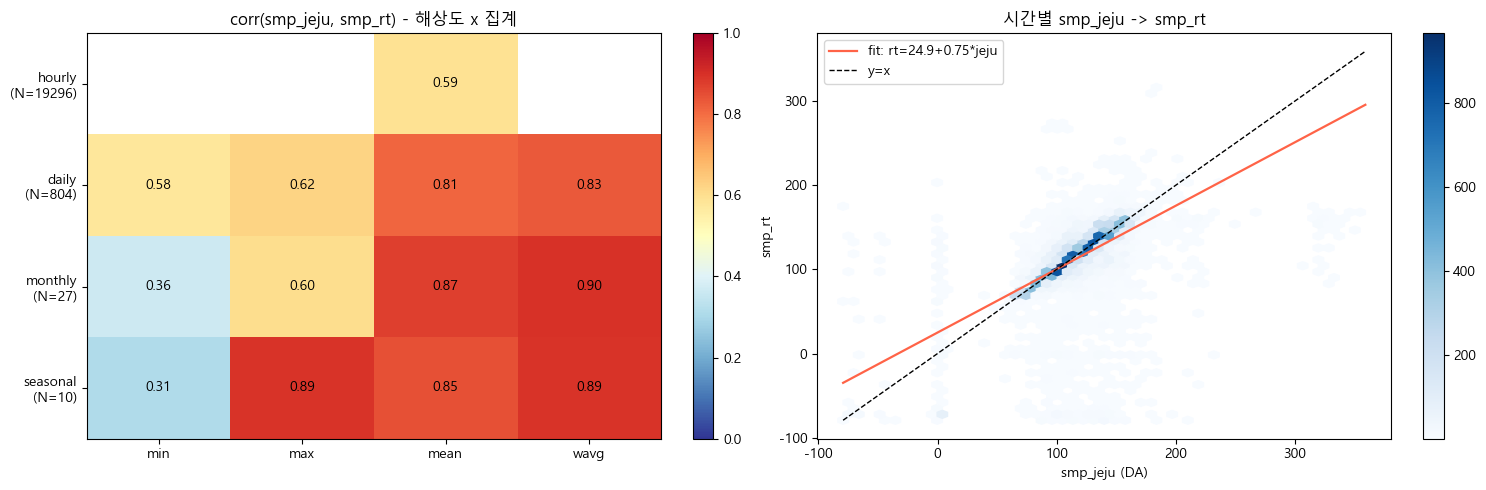

[Step 5] DA(smp_jeju)를 RT baseline 으로? - 상관/오차 리포트
[corr(smp_jeju, smp_rt)  - 해상도 x 집계]
            min    max   mean   wavg
hourly      NaN    NaN  0.592    NaN
daily     0.578  0.623  0.809  0.831
monthly   0.364  0.604  0.873  0.897
seasonal  0.309  0.893  0.845  0.893
표본수 N : {'hourly': 19296, 'daily': 804, 'monthly': 27, 'seasonal': 10}
  ※ monthly·seasonal 은 N이 작아 상관이 불안정 - 참고용.

[레벨 vs 1차 차분 상관 (허위추세 점검)]
  시간별 : 레벨 0.592  vs  차분 0.091
  일별   : 레벨 0.809  vs  차분 0.704

[smp_jeju 를 그대로 예측치로 썼을 때 오차 (원/kWh)]
  시간별 : bias -3.90  MAE 13.76  RMSE 34.03
  일평균 : bias -3.90  MAE 6.53  RMSE 13.25
  회귀   : rt = 24.94 + 0.754*jeju   (R^2=0.350)

→ 레벨·차분 상관이 높고 bias/RMSE가 작으며 기울기 b가 1에 가까우면 smp_jeju 를 RT baseline 으로 채택.
  b가 1에서 벗어나면 보정계수 필요(예: 한낮 태양광 할인 - Step 2/4 참조).


In [8]:
j   = df['smp_jeju']
r   = df[TARGET]
dmd = df['real_demand']

keys = {
    'daily':    df.index.to_period('D'),
    'monthly':  df.index.to_period('M'),
    'seasonal': pd.Series([f'{ts.year}-{SEASON[ts.month]}' for ts in df.index], index=df.index),
}

def wavg_grp(price, key):
    return (price * dmd).groupby(key).sum() / dmd.groupby(key).sum()

rows, ncnt = {}, {}
rows[('hourly', 'mean')] = j.corr(r)
ncnt['hourly'] = int(j.notna().sum())
for rname, key in keys.items():
    for aname, fn in [('min', 'min'), ('max', 'max'), ('mean', 'mean')]:
        rows[(rname, aname)] = j.groupby(key).agg(fn).corr(r.groupby(key).agg(fn))
    rows[(rname, 'wavg')] = wavg_grp(j, key).corr(wavg_grp(r, key))
    ncnt[rname] = r.groupby(key).mean().shape[0]

res_order = ['hourly', 'daily', 'monthly', 'seasonal']
agg_order = ['min', 'max', 'mean', 'wavg']
corr_tbl = pd.DataFrame(index=res_order, columns=agg_order, dtype=float)
for (rn, an), v in rows.items():
    corr_tbl.loc[rn, an] = v

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
M = corr_tbl.astype(float).values
im = ax.imshow(np.ma.masked_invalid(M), cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(agg_order))); ax.set_xticklabels(agg_order)
ax.set_yticks(range(len(res_order))); ax.set_yticklabels([f'{rn}\n(N={ncnt[rn]})' for rn in res_order])
for i in range(M.shape[0]):
    for k in range(M.shape[1]):
        if not np.isnan(M[i, k]):
            ax.text(k, i, f'{M[i, k]:.2f}', ha='center', va='center', color='black')
ax.set_title('corr(smp_jeju, smp_rt) - 해상도 x 집계')
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
mask = j.notna() & r.notna()
jv, rv = j[mask].values, r[mask].values
hb = ax.hexbin(jv, rv, gridsize=50, cmap='Blues', mincnt=1)
b, a = np.polyfit(jv, rv, 1)
xs = np.array([jv.min(), jv.max()])
ax.plot(xs, a + b * xs, color='tomato', linewidth=1.6, label=f'fit: rt={a:.1f}+{b:.2f}*jeju')
ax.plot(xs, xs, color='black', linestyle='--', linewidth=1, label='y=x')
ax.set_title('시간별 smp_jeju -> smp_rt')
ax.set_xlabel('smp_jeju (DA)'); ax.set_ylabel('smp_rt'); ax.legend()
fig.colorbar(hb, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# 텍스트 리포트
def da_err(actual, pred):
    e = (actual - pred).dropna()
    return e.mean(), e.abs().mean(), np.sqrt((e ** 2).mean())

rt_d, jj_d = r.resample('D').mean(), j.resample('D').mean()
bias_h, mae_h, rmse_h = da_err(r, j)
bias_d, mae_d, rmse_d = da_err(rt_d, jj_d)
corr_diff_h = j.diff().corr(r.diff())
corr_diff_d = jj_d.diff().corr(rt_d.diff())
r2 = corr_tbl.loc['hourly', 'mean'] ** 2

print('=' * 60)
print('[Step 5] DA(smp_jeju)를 RT baseline 으로? - 상관/오차 리포트')
print('=' * 60)
print('[corr(smp_jeju, smp_rt)  - 해상도 x 집계]')
print(corr_tbl.round(3).to_string())
print(f'표본수 N : {ncnt}')
print('  ※ monthly·seasonal 은 N이 작아 상관이 불안정 - 참고용.')
print()
print('[레벨 vs 1차 차분 상관 (허위추세 점검)]')
print(f'  시간별 : 레벨 {corr_tbl.loc["hourly","mean"]:.3f}  vs  차분 {corr_diff_h:.3f}')
print(f'  일별   : 레벨 {corr_tbl.loc["daily","mean"]:.3f}  vs  차분 {corr_diff_d:.3f}')
print()
print('[smp_jeju 를 그대로 예측치로 썼을 때 오차 (원/kWh)]')
print(f'  시간별 : bias {bias_h:+.2f}  MAE {mae_h:.2f}  RMSE {rmse_h:.2f}')
print(f'  일평균 : bias {bias_d:+.2f}  MAE {mae_d:.2f}  RMSE {rmse_d:.2f}')
print(f'  회귀   : rt = {a:.2f} + {b:.3f}*jeju   (R^2={r2:.3f})')
print()
print('→ 레벨·차분 상관이 높고 bias/RMSE가 작으며 기울기 b가 1에 가까우면 smp_jeju 를 RT baseline 으로 채택.')
print('  b가 1에서 벗어나면 보정계수 필요(예: 한낮 태양광 할인 - Step 2/4 참조).')

## Step 6 - DA vs same-hour naive (빠른 확인)

**목표**: Step 5 명제 보강. 시간별 SMP는 24h 주기가 강해 임의 lag 지속성은 위상 왜곡 → **같은 시각 d일 전 값(lag 24·48·72…)** 만 비교한다. lag 0 = day-ahead `smp_jeju`(사전 가용 기준선). DA가 모든 same-hour 지속성보다 오차가 작으면 "DA를 RT baseline으로"가 확정.

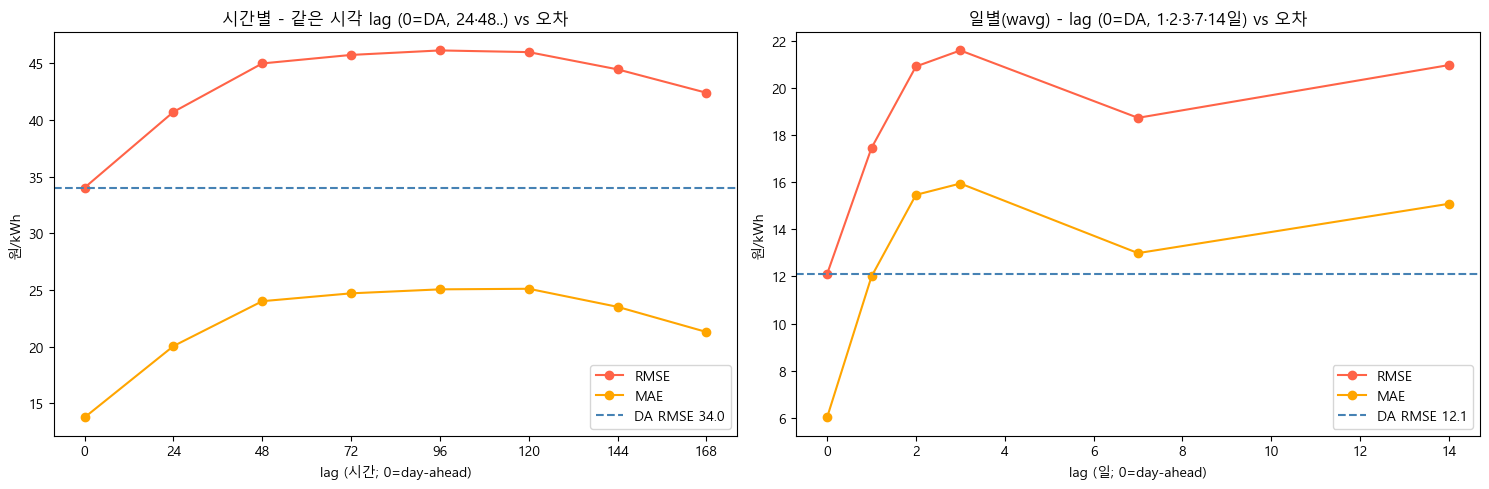

[Step 6] DA vs same-hour naive 빠른 확인
[시간별]  (lag 0 = day-ahead smp_jeju)
         MAE   RMSE        method
lag_h                            
0      13.76  34.03  DA(smp_jeju)
24     20.05  40.72     rt(t-24h)
48     24.01  44.99     rt(t-48h)
72     24.70  45.74     rt(t-72h)
96     25.06  46.14     rt(t-96h)
120    25.11  45.99    rt(t-120h)
144    23.51  44.47    rt(t-144h)
168    21.29  42.40    rt(t-168h)
-> DA RMSE 34.03  vs  best same-hour naive RMSE 40.72

[일별(wavg)]  (lag 0 = day-ahead smp_jeju wavg)
         MAE   RMSE
lag_d              
0       6.02  12.10
1      12.00  17.45
2      15.46  20.91
3      15.94  21.59
7      12.99  18.73
14     15.08  20.97
-> DA RMSE 12.10  vs  best naive RMSE 17.45

→ DA(smp_jeju)가 모든 same-hour 지속성보다 오차 작음 ⇒ DA를 RT baseline으로 확정.


In [9]:
def err(actual, pred):
    e = (actual - pred).dropna()
    return e.abs().mean(), np.sqrt((e ** 2).mean())

# ── 시간별 : lag 0 = DA, lag 24·48… = 같은 시각 d일 전 ──
y_h = df[TARGET]
da_mae_h, da_rmse_h = err(y_h, df['smp_jeju'])
lags = [24, 48, 72, 96, 120, 144, 168]
rows = [(0, da_mae_h, da_rmse_h, 'DA(smp_jeju)')]
for L in lags:
    mae, rmse = err(y_h, y_h.shift(L))
    rows.append((L, mae, rmse, f'rt(t-{L}h)'))
dec = pd.DataFrame(rows, columns=['lag_h', 'MAE', 'RMSE', 'method']).set_index('lag_h')

# ── 일별(wavg) : lag 0 = DA(일 wavg), lag k = k일 전 ──
y_d = daily_wavg(TARGET)
jd  = daily_wavg('smp_jeju')
da_mae_d, da_rmse_d = err(y_d, jd)
rows_d = [(0, da_mae_d, da_rmse_d)]
for k in [1, 2, 3, 7, 14]:
    mae, rmse = err(y_d, y_d.shift(k))
    rows_d.append((k, mae, rmse))
dec_d = pd.DataFrame(rows_d, columns=['lag_d', 'MAE', 'RMSE']).set_index('lag_d')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(dec.index, dec['RMSE'], color='tomato', marker='o', label='RMSE')
ax.plot(dec.index, dec['MAE'],  color='orange', marker='o', label='MAE')
ax.axhline(da_rmse_h, color='steelblue', linestyle='--', label=f'DA RMSE {da_rmse_h:.1f}')
ax.set_title('시간별 - 같은 시각 lag (0=DA, 24·48..) vs 오차')
ax.set_xlabel('lag (시간; 0=day-ahead)'); ax.set_ylabel('원/kWh')
ax.set_xticks([0] + lags); ax.legend()

ax = axes[1]
ax.plot(dec_d.index, dec_d['RMSE'], color='tomato', marker='o', label='RMSE')
ax.plot(dec_d.index, dec_d['MAE'],  color='orange', marker='o', label='MAE')
ax.axhline(da_rmse_d, color='steelblue', linestyle='--', label=f'DA RMSE {da_rmse_d:.1f}')
ax.set_title('일별(wavg) - lag (0=DA, 1·2·3·7·14일) vs 오차')
ax.set_xlabel('lag (일; 0=day-ahead)'); ax.set_ylabel('원/kWh'); ax.legend()

plt.tight_layout()
plt.show()

# 텍스트 리포트
best_naive_h = dec.loc[lags, 'RMSE'].min()
best_naive_d = dec_d.loc[[1, 2, 3, 7, 14], 'RMSE'].min()

print('=' * 60)
print('[Step 6] DA vs same-hour naive 빠른 확인')
print('=' * 60)
print('[시간별]  (lag 0 = day-ahead smp_jeju)')
print(dec.round(2).to_string())
print(f'-> DA RMSE {da_rmse_h:.2f}  vs  best same-hour naive RMSE {best_naive_h:.2f}')
print()
print('[일별(wavg)]  (lag 0 = day-ahead smp_jeju wavg)')
print(dec_d.round(2).to_string())
print(f'-> DA RMSE {da_rmse_d:.2f}  vs  best naive RMSE {best_naive_d:.2f}')
print()
if da_rmse_h <= best_naive_h and da_rmse_d <= best_naive_d:
    print('→ DA(smp_jeju)가 모든 same-hour 지속성보다 오차 작음 ⇒ DA를 RT baseline으로 확정.')
else:
    print('→ 일부 lag에서 naive가 더 나음 ⇒ 해당 구간만 지속성 보정 고려.')

## Phase 3 요약

(결과는 `report.ipynb`의 Phase 3 digest로 정리됨.)

- **Step 1** — 시간별 레벨 corr 0.59지만 차분 0.09(추세 동조). RT가 더 변동적(std 40.8 > jeju 32.0).
- **Step 2** — 한낮(10~13시) jeju−rt 격차 급증(태양광), 야간·저녁은 미미. Phase-2 한낮 현상이 실제 타깃에서 더 강함.
- **Step 3** — 음(−)SMP: jeju 0.39% vs rt 2.88%(neg_flag 4.22%) → RT 음SMP 구간이 훨씬 넓고 한낮 집중.
- **Step 4** — 격차 std 최상위 = **봄 한낮(10~13시)** = 예측 주의 구간(태양광 과잉 → RT 급락). 여름이 가장 안정.
- **Step 5** — DA(smp_jeju)는 RT baseline으로 채택. 일/wavg 강함(MAE≈6.5), 시간별·극값 약함. 보정식 `rt≈24.94+0.754·jeju` (R²=0.35).
- **Step 6** — DA RMSE가 모든 same-hour 지속성보다 작음 → DA baseline 확정 보강.